In [2]:
#7.1
import numpy as np
import numpy.linalg as la

A = np.array([[1,  2,  3], [0, -4,  1], [0,  3, -1]])
#1
det_A = la.det(A)
#2
B = np.array([2, 2, -1])
solution = la.solve(A, B)
#3
orthog = np.allclose(np.dot(A.T, A), np.eye(3))
#4
eigenvalues, eigenvectors = la.eig(A)

print(f"Determinant: {det_A:.2f}")
print(f"Solution: {solution}")
print(f"Orthogonal: {orthog}")
print(f"Eigenvalues: {eigenvalues}")

Determinant: 1.00
Solution: [10. -1. -2.]
Orthogonal: False
Eigenvalues: [ 1.         -4.79128785 -0.20871215]


In [17]:
#7.3
import numpy as np
from numpy import linalg as la

a1 = np.radians(180 - 123)
a2 = np.radians(90 - 27.4)
a3 = np.radians(192.25)

Ex = np.array([[np.cos(a1), np.sin(a1), 0], [-np.sin(a1), np.cos(a1), 0], [0, 0, 1]])
Ey = np.array([[np.cos(a2), 0, -np.sin(a2)], [0, 1, 0], [np.sin(a2), 0, np.cos(a2)]])
Ez = np.array([[np.cos(a3), np.sin(a3), 0], [-np.sin(a3), np.cos(a3), 0], [0, 0, 1]])
E = Ex @ Ey @ Ez
print(E)

ra, dec = np.radians(192.25), np.radians(27.4)
v = np.array([np.cos(dec)*np.cos(ra), np.cos(dec)*np.sin(ra), np.sin(dec)])
v2 = E @ v

orthog = np.allclose(E.T @ E, np.eye(3))
det_E = la.det(E)
print()
print(f"Orthogonal: {orthog}")
print(f"Determinant: {det_E:.1f}")
print('Thus E is a rotation matrix')

eigenvals, eigenvectors = la.eig(E)
print(f"eigenvalues: {eigenvals}")
print('E has at least one eigenvalue equal to 1')
print()
print(f'v = {v}')
print('This corresponds to the matrix given in the question')
print()
print(f'E @ v = {v2}')
print('This result for v2 is nearly the same as being [0, 0, 1], thus this represents the galactic pole')

[[-0.06698874 -0.87275577 -0.48353891]
 [ 0.49272847 -0.45034696  0.74458463]
 [-0.86760081 -0.1883746   0.46019978]]

Orthogonal: True
Determinant: 1.0
Thus E is a rotation matrix
eigenvalues: [-0.52856796+0.84889099j -0.52856796-0.84889099j  1.        +0.j        ]
E has at least one eigenvalue equal to 1

v = [-0.86760081 -0.1883746   0.46019978]
This corresponds to the matrix given in the question

E @ v = [2.45631360e-17 2.95515309e-17 1.00000000e+00]
This result for v2 is nearly the same as being [0, 0, 1], thus this represents the galactic pole


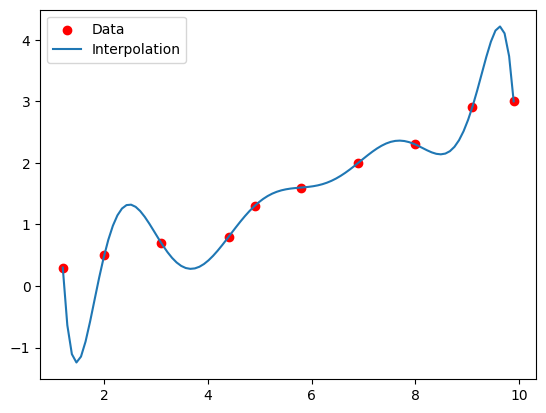

Coefficients: [-2.17117476e-04  1.09925609e-02 -2.39059756e-01  2.91867714e+00
 -2.19331359e+01  1.04544074e+02 -3.13633556e+02  5.65812237e+02
 -5.51003146e+02  2.18582332e+02]


In [19]:
#7.5
import numpy as np
import matplotlib.pyplot as plt
from numpy import linalg as la

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

n = len(x)
A = np.zeros((n, n))
for i in range(n):
    for j in range(n):
        A[i, j] = x[i]**(n-1-j)

c = la.solve(A, y)

x_smooth = np.linspace(min(x), max(x), 100)
y_poly = 0
for j in range(n):
    y_poly += c[j] * x_smooth**(n-1-j)

plt.scatter(x, y, color='red', label='Data')
plt.plot(x_smooth, y_poly, label='Interpolation')
plt.legend()
plt.show()

print("Coefficients:", c)


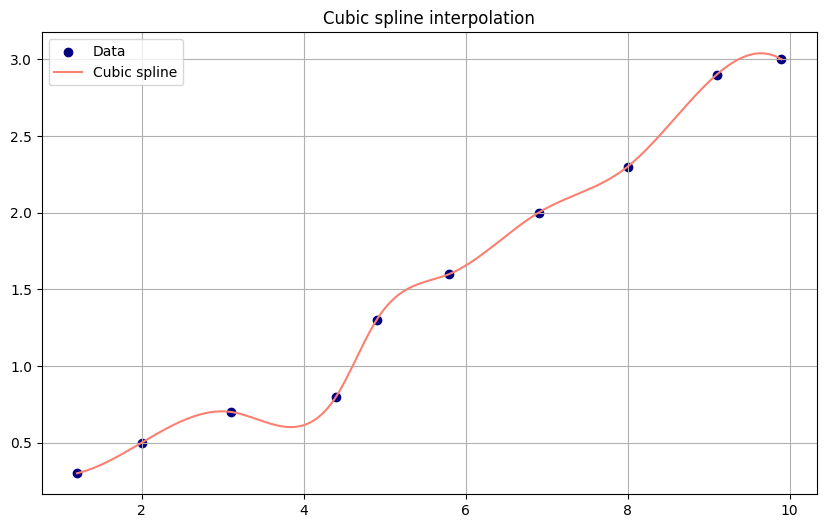

input desired test value for x: 2.8
Results at x = 2.5:
Linear:     0.6455
Polynomial: 1.1024
Spline:     0.6935


In [26]:
#7.6
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from numpy import linalg as la

x_data = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y_data = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])
#1
f_cubic = interp1d(x_data, y_data, kind='cubic')
x_dense = np.linspace(1.2, 9.9, 200)
y_cubic = f_cubic(x_dense)
#2
print('at the edges a high degree polynomial interpolation will oscilate wildly whereas splines wont')

plt.figure(figsize=(10, 6))
plt.scatter(x_data, y_data, color='navy', label='Data')
plt.plot(x_dense, y_cubic, color='salmon', label='Cubic spline')
plt.title("Cubic spline interpolation")
plt.legend()
plt.grid(True)
plt.show()
#3 4
class interpolation:
    def __init__(self, x, y):
        self.x = x
        self.y = y
        self.n = len(x)
       
    def calculate(self, x_input, method='spline'):
        if method == 'linear':
            f = interp1d(self.x, self.y, kind='linear')
            return f(x_input)
           
        elif method == 'spline':
            f = interp1d(self.x, self.y, kind='cubic')
            return f(x_input)
           
        elif method == 'polynomial':
            A = np.zeros((self.n, self.n))
            for i in range(self.n):
                for j in range(self.n):
                    A[i, j] = self.x[i]**(self.n - 1 - j)
            coeffs = la.solve(A, self.y)
            
            if isinstance(x_input, (list, np.ndarray)):
                res = np.zeros_like(x_input, dtype=float)
                for j in range(self.n):
                    res += coeffs[j] * x_input**(self.n - 1 - j)
                return res
            else:
                res = 0
                for j in range(self.n):
                    res += coeffs[j] * x_input**(self.n - 1 - j)
                return res
#5
obj = interpolation(x_data, y_data)
inputval = float(input('input desired test value for x: '))

val_linear = obj.calculate(inputval, 'linear')
val_poly = obj.calculate(inputval, 'polynomial')
val_spline = obj.calculate(inputval, 'spline')

print(f"Results at x = {test_val}:")
print(f"Linear:     {val_linear:.4f}")
print(f"Polynomial: {val_poly:.4f}")
print(f"Spline:     {val_spline:.4f}")



In [28]:
#7.7
import numpy as np
I=np.array([[2.0, 4.1], [2.5, 3.8]])
x = 0.2
y = 0.7
Iip = (1-x)*(1-y)*I[0, 0] + x*(1-y)*I[0,1]+y*(1-x)*I[1,0] + x*y*I[1,1]
print(F"The interpolated intensity : {Iip:.4f}")

The interpolated intensity : 2.6580


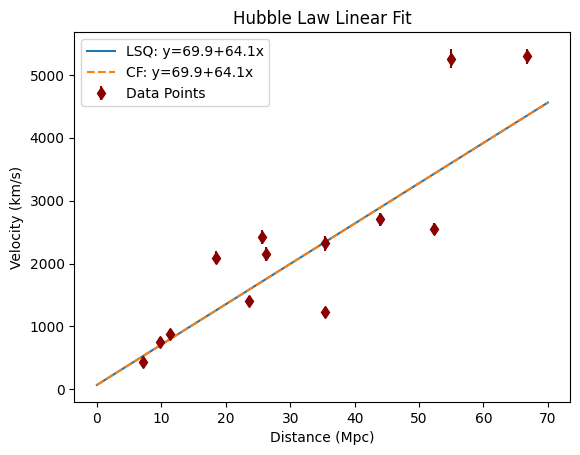

In [29]:
#7.10
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq, curve_fit

data = np.array([
    [18.49, 2094.75, 0.3, 100],
    [35.48, 2320.87, 2.2, 120],
    [35.48, 1224.9, 3.0, 80],
    [11.34, 872.13, 1.2, 80],
    [7.12, 432.2, 0.4, 70],
    [9.82, 751, 0.3, 75],
    [23.66, 1410, 2.3, 70],
    [44, 2700, 4.0, 110],
    [66.7, 5292, 5.3, 120],
    [52.4, 2550, 5.2, 100],
    [55, 5253, 6.1, 150],
    [25.6, 2419, 3.2, 110],
    [26.19, 2158, 2.8, 110]
])

dist = data[:,0]
vel = data[:,1]
vel_err = data[:,3]

def res_func(p, x, y, err):
    return (y - (p[0] + p[1] * x)) / err

def model_func(x, a, b):
    return a + b * x

p_lsq, _ = leastsq(res_func, [0, 50], args=(dist, vel, vel_err))

p_cf, _ = curve_fit(model_func, dist, vel, sigma=vel_err, absolute_sigma=True)

plt.errorbar(dist, vel, yerr=vel_err, fmt='d', color='darkred', label='Data Points')

x_range = np.linspace(0, 70, 100)
plt.plot(x_range, model_func(x_range, *p_lsq), label=f'LSQ: y={p_lsq[0]:.1f}+{p_lsq[1]:.1f}x')
plt.plot(x_range, model_func(x_range, *p_cf), '--', label=f'CF: y={p_cf[0]:.1f}+{p_cf[1]:.1f}x')

plt.xlabel('Distance (Mpc)')
plt.ylabel('Velocity (km/s)')
plt.title('Hubble Law Linear Fit')
plt.legend()
plt.show()